In [1]:
import os
import h5py
from H2Crop import H2Crop
import sys
import matplotlib.pyplot as plt
import numpy as np

In [2]:
H2Crop_dataset = H2Crop()

In [3]:
data = H2Crop_dataset.get_random_h5_sample()

if data:
    print(f"\nExtracted Array Shapes:")
    print(f" - Hyperspectral: {data['hyperspectral'].shape}")
    print(f" - Multispectral: {data['multispectral'].shape}")
    print(f" - Labels:        {data['labels'].shape}")
    print(f" - Priors:        {data['prior'].shape}")


Extracted Array Shapes:
 - Hyperspectral: (218, 64, 64)
 - Multispectral: (12, 10, 192, 192)
 - Labels:        (4, 192, 192)
 - Priors:        (4, 192, 192)


In [ ]:
list_files = H2Crop_dataset.get_file_list(from_train=False, limit=1600)
data = H2Crop_dataset.load_h5_data(file_list=list_files, keep_prior=False, data_type="multispectral", detail_layer=0, static=True)

# for sample in data:
#     print(f"\nExtracted Array Shapes:")
#     print(f" - Hyperspectral: {sample['hyperspectral'].shape}")
#     print(f" - Labels:        {sample['labels'].shape}")
#     print('\n')

Successfully sampled 1600 file IDs.


In [5]:
def check_ram_usage(data, RAM=1):
    tot_bytes = 0

    for sample in data:
        for key,value in sample.items():
            if hasattr(value, 'nbytes'):
                tot_bytes += value.nbytes
    
    RAM_bytes = RAM * 1024 * 1024 * 1024

    print(f'RAM usage (bytes): {tot_bytes} | {RAM_bytes}')
    print(f'RAM usage (%): {round((tot_bytes * 100) / (RAM_bytes), 2)}%')

In [6]:
check_ram_usage(data=data, RAM=16)

RAM usage (bytes): 2916352000 | 17179869184
RAM usage (%): 16.98%


# PLOT IMAGES

In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

def visualize_sample(dataset_dict):
    """
    Visualizes the Sentinel-2 multispectral data in True RGB and 
    the Level 1 crop labels side-by-side, with a text-based class legend.
    """
    # --- 1. Extract and Normalize Sentinel-2 Data ---
    s2_data = dataset_dict['multispectral']
    r_band = s2_data[2, :, :] 
    g_band = s2_data[1, :, :] 
    b_band = s2_data[0, :, :] 
    
    rgb_image = np.stack([r_band, g_band, b_band], axis=-1)
    
    # 98th percentile normalization for satellite imagery
    vmax = np.percentile(rgb_image, 98)
    vmin = np.percentile(rgb_image, 2)
    rgb_normalized = np.clip((rgb_image - vmin) / (vmax - vmin), 0, 1)
    
    # --- 2. Extract Level 1 Labels ---
    level_1_labels = dataset_dict['labels'][0]
    
    # --- 3. Define the Class Names ---
    # Update these based on the exact mapping in the repository's metadata!
    level_1_names = [
        "Arable Crops", 
        "Permanent Crops", 
        "Pastures / Grassland", 
        "Unmaintained", 
        "Forestry / Trees", 
        "Other / Unspecified"
    ]
    
    # --- 4. Create the Plot ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 6)) # Made slightly wider for the legend
    
    # Plot Sentinel-2 RGB
    axes[0].imshow(rgb_normalized)
    axes[0].set_title('Sentinel-2 Multispectral (True RGB)\nResolution: 192x192 (10m/pixel)')
    axes[0].axis('off')
    
    # Plot Level 1 Labels
    cmap = plt.get_cmap('Set1', 6) 
    im = axes[1].imshow(level_1_labels, cmap=cmap, interpolation='nearest')
    axes[1].set_title('Level 1 Crop Labels\nResolution: 192x192 (10m/pixel)')
    axes[1].axis('off')
    
    # --- 5. Create Custom Text Legend ---
    # We create a little colored box (patch) for each class name
    legend_patches = [
        mpatches.Patch(color=cmap(i), label=f"{i}: {level_1_names[i]}") 
        for i in range(6)
    ]
    
    # Add the legend to the right side of the label plot (bbox_to_anchor places it perfectly outside)
    axes[1].legend(
        handles=legend_patches, 
        loc='center left', 
        bbox_to_anchor=(1.05, 0.5), 
        title="Level 1 Classes",
        frameon=False
    )
    
    plt.tight_layout()
    plt.show()

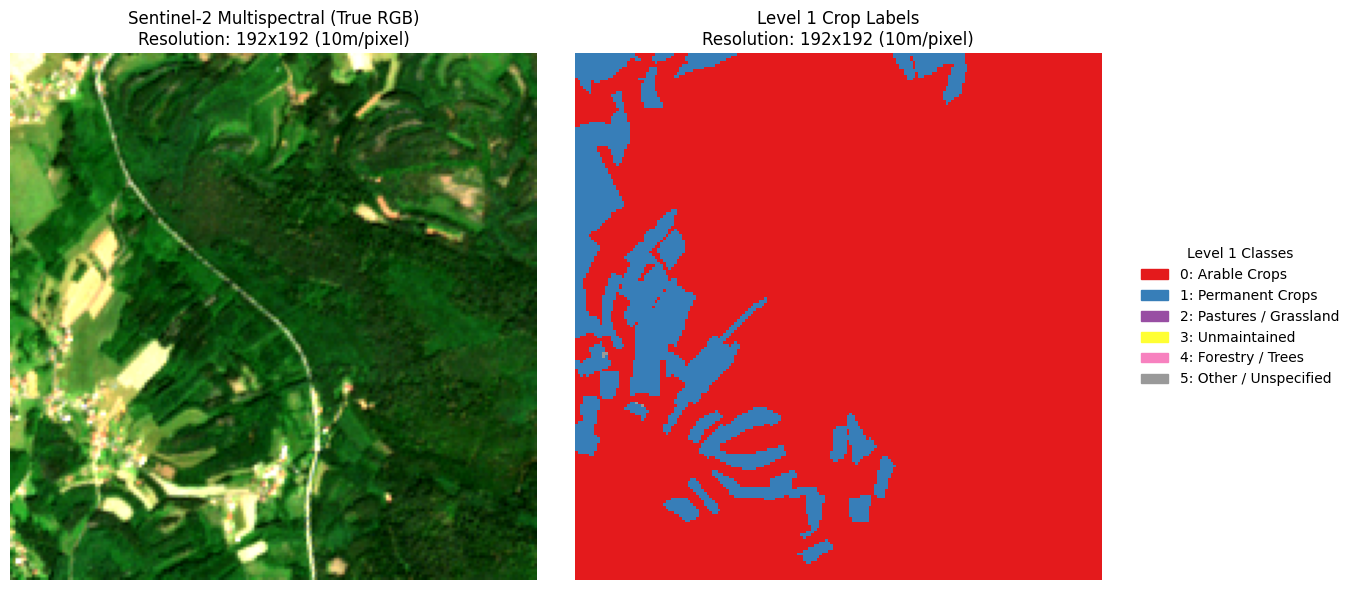

In [8]:
# Assuming you already instantiated your H2Crop class and loaded a sample:
loader = H2Crop()
my_sample = loader.get_random_h5_sample(static=True)
visualize_sample(my_sample)